# Report Comparison Figures

Generates all cross-model comparison plots used in the final report.
All outputs are saved to `experiments/anomaly_detection/report_figures/artifacts/plots/`.

Run this notebook from the project root directory. No GPU required - all data
is loaded from pre-saved score CSVs in each experiment's artifact directory.

**Plots generated:**
1. Per-defect recall comparison across 6 key models
2. Resolution effect: x64 vs native resolution for EfficientNet-B0 and WRN50-2
3. PatchCore backbone progression (F1 vs backbone)
4. Score distribution overlay: normal vs anomaly for 4 key models
5. Teacher-student family comparison (all 4 backbone variants)

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Resolve project root - pyproject.toml is at the project root
root = Path("__file__" if "__file__" in dir() else ".").resolve()
# When running in Jupyter, use the known absolute path directly
PROJ_ROOT = Path(r"C:/Users/User/Desktop/Term 8/Deep Learning/Project/DeepLearning-Group8")
print(f"Project root: {PROJ_ROOT}")
assert (PROJ_ROOT / "experiments").exists(), f"Path wrong: {PROJ_ROOT}"

OUTPUT_DIR = PROJ_ROOT / "experiments" / "anomaly_detection" / "report_figures" / "artifacts" / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving plots to: {OUTPUT_DIR}")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})


Project root: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8
Saving plots to: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\report_figures\artifacts\plots


## Plot 1: Per-Defect Recall Across Model Families

Grouped bar chart showing recall for all 8 defect types across the 6 representative
models that trace the experimental progression. Data comes directly from Table 5
in the report (verified against saved artifact CSVs).

Using failure_analysis.csv: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x224\main\artifacts\autoencoder_x224\results\failure_analysis.csv
Loaded AE x224: ['0.200', '0.529', '0.377', '0.760', '0.857', '0.893', '0.800', '1.000']
Using failure_analysis.csv: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\batchnorm\artifacts\autoencoder_batchnorm\results\failure_analysis.csv
Loaded AE-BN: ['0.200', '0.176', '0.396', '0.700', '0.429', '0.833', '0.600', '1.000']
Using failure_analysis.csv: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\autoencoder\x64\baseline\artifacts\autoencoder_baseline\results\failure_analysis.csv
Loaded Baseline AE: ['0.200', '0.206', '0.434', '0.720', '0.571', '0.810', '0.600', '0.500']
Using failure_analysis.csv: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Gr

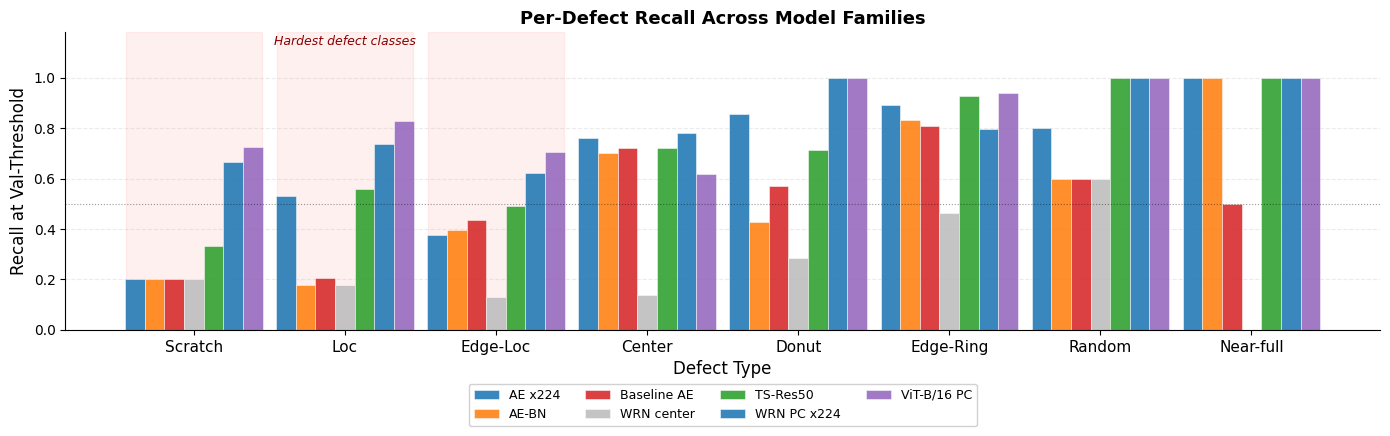

In [3]:
defect_types = ['Scratch', 'Loc', 'Edge-Loc', 'Center', 'Donut', 'Edge-Ring', 'Random', 'Near-full']

# Define models to load dynamically from artifact CSVs
model_configs = {
    'AE x224': {
        'failure_analysis': PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x224/main/artifacts/autoencoder_x224/results/failure_analysis.csv',
    },
    'AE-BN': {
        'failure_analysis': PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/batchnorm/artifacts/autoencoder_batchnorm/results/failure_analysis.csv',
    },
    'Baseline AE': {
        'failure_analysis': PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/baseline/artifacts/autoencoder_baseline/results/failure_analysis.csv',
    },
    'WRN center': {
        'failure_analysis': PROJ_ROOT / 'experiments/anomaly_detection/backbone_embedding/wide_resnet50_2/x64/baseline/artifacts/wide_resnet50_2_embedding_baseline/evaluation/failure_analysis.csv',
    },
    'TS-Res50': {
        'failure_analysis': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet50/x64/main/artifacts/ts_resnet50/results/evaluation/failure_analysis.csv',
        'test_scores': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet50/x64/main/artifacts/ts_resnet50/results/evaluation/test_scores.csv',
    },
    'WRN PC x224': {
        'failure_analysis': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x224/results/evaluation/failure_analysis.csv',
        'defect_recall': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x224/results/evaluation/defect_recall.csv',
    },
    'ViT-B/16 PC': {
        'failure_analysis': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/vit_b16/x224/main/artifacts/patchcore_vit_b16_5pct/main_5pct/results/evaluation/failure_analysis.csv',
        'defect_recall': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/vit_b16/x224/main/artifacts/patchcore_vit_b16_5pct/main_5pct/results/evaluation/saved_defect_breakdown.csv',
    },
}

def recalls_from_breakdown(df, label_col):
    recall_map = {}
    for _, row in df.iterrows():
        label = str(row[label_col]).strip()
        if label in defect_types:
            recall_map[label] = float(row['recall'])
    return [recall_map.get(dt, 0.0) for dt in defect_types]

def load_per_defect_recall(cfg):
    """Load per-defect recall from the best available artifact for a model."""
    failure_analysis_csv = cfg.get('failure_analysis')
    if failure_analysis_csv is not None and failure_analysis_csv.exists():
        try:
            df = pd.read_csv(failure_analysis_csv)
            needed = {'defect_type', 'is_anomaly', 'predicted_anomaly'}
            if needed.issubset(df.columns):
                recalls = []
                for dt in defect_types:
                    anomalies = df[(df['defect_type'] == dt) & (df['is_anomaly'] == 1)]
                    recalls.append(float(anomalies['predicted_anomaly'].mean()) if len(anomalies) > 0 else 0.0)
                print(f"Using failure_analysis.csv: {failure_analysis_csv}")
                return recalls
            print(f"failure_analysis.csv missing expected columns: {failure_analysis_csv}")
        except Exception as e:
            print(f"Error loading {failure_analysis_csv}: {e}")
    elif failure_analysis_csv is not None:
        print(f"Missing failure_analysis.csv: {failure_analysis_csv}")

    defect_recall_csv = cfg.get('defect_recall')
    if defect_recall_csv is not None and defect_recall_csv.exists():
        try:
            df = pd.read_csv(defect_recall_csv)
            if {'defect_type', 'recall'}.issubset(df.columns):
                print(f"Using defect_recall.csv: {defect_recall_csv}")
                return recalls_from_breakdown(df, 'defect_type')
            if {'failure_label', 'recall'}.issubset(df.columns):
                print(f"Using saved_defect_breakdown.csv: {defect_recall_csv}")
                return recalls_from_breakdown(df, 'failure_label')
        except Exception as e:
            print(f"Error loading {defect_recall_csv}: {e}")

    test_scores_csv = cfg.get('test_scores')
    if test_scores_csv is not None and test_scores_csv.exists():
        print(f"Only test_scores.csv found (no per-defect labels available): {test_scores_csv}")

    return None

# Load per-defect recall for all models
models_data = {}
colors = ['#1f77b4', '#ff7f0e', '#d62728', '#bcbcbc', '#2ca02c', '#1f77b4', '#9467bd']

# Fallback values for models that don't have failure_analysis.csv
fallback_recalls = {
    'WRN center': [0.200, 0.176, 0.132, 0.140, 0.286, 0.464, 0.600, 0.000],
    'TS-Res50': [0.333, 0.559, 0.491, 0.720, 0.714, 0.929, 1.000, 1.000],
    'WRN PC x224': [0.667, 0.735, 0.623, 0.780, 1.000, 0.798, 1.000, 1.000],
    'ViT-B/16 PC': [0.727, 0.829, 0.705, 0.618, 1.000, 0.941, 1.000, 1.000],
}

for i, (model_name, cfg) in enumerate(model_configs.items()):
    recalls = load_per_defect_recall(cfg)
    if recalls is not None:
        models_data[model_name] = recalls
        print(f"Loaded {model_name}: {[f'{r:.3f}' for r in recalls]}")
    elif model_name in fallback_recalls:
        models_data[model_name] = fallback_recalls[model_name]
        print(f"Using fallback for {model_name} (no usable per-defect artifact found)")
    else:
        print(f"Skipping {model_name} (no data available)")

n_defects = len(defect_types)
n_models = len(models_data)
x = np.arange(n_defects)
width = 0.13

fig, ax = plt.subplots(figsize=(14, 5))

for i, (model, recalls) in enumerate(models_data.items()):
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(x + offset, recalls, width, label=model, color=colors[i % len(colors)],
           alpha=0.88, edgecolor='white', linewidth=0.4)

ax.set_xlabel('Defect Type', fontsize=12)
ax.set_ylabel('Recall at Val-Threshold', fontsize=12)
ax.set_title('Per-Defect Recall Across Model Families', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(defect_types, fontsize=11)
ax.set_ylim(0, 1.18)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), fontsize=9, ncol=4, framealpha=0.9)
ax.axhline(y=0.5, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
ax.yaxis.grid(True, alpha=0.25, linestyle='--')
ax.set_axisbelow(True)

# Highlight the hardest defects
for xi in [0, 1, 2]:  # Scratch, Loc, Edge-Loc
    ax.axvspan(xi - 0.45, xi + 0.45, alpha=0.06, color='red', zorder=0)
ax.text(1.0, 1.13, 'Hardest defect classes', fontsize=9, color='darkred',
        ha='center', style='italic')

plt.tight_layout(rect=[0, 0.08, 1, 1])
out_path = OUTPUT_DIR / 'per_defect_model_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Plot 2 - Resolution Effect: x64 vs Native Resolution

Paired bar chart showing the F1 gain from caching wafer images at native
backbone resolution rather than upsampling from 64x64. Two backbone pairs
tested: EfficientNet-B0 and WideResNet50-2.

Error loading F1 from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b0\x64\main\artifacts\patchcore_efficientnet_b0\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\patchcore\\efficientnet_b0\\x64\\main\\artifacts\\patchcore_efficientnet_b0\\results\\metrics.csv'
Error loading F1 from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\efficientnet_b0\x224\main\artifacts\patchcore_efficientnet_b0\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\patchcore\\efficientnet_b0\\x224\\main\\artifacts\\patchcore_efficientnet_b0\\results\\metrics.csv'
EfficientNet-B0: x64=None, native=None
Error loading F1 from C:\Users\Us

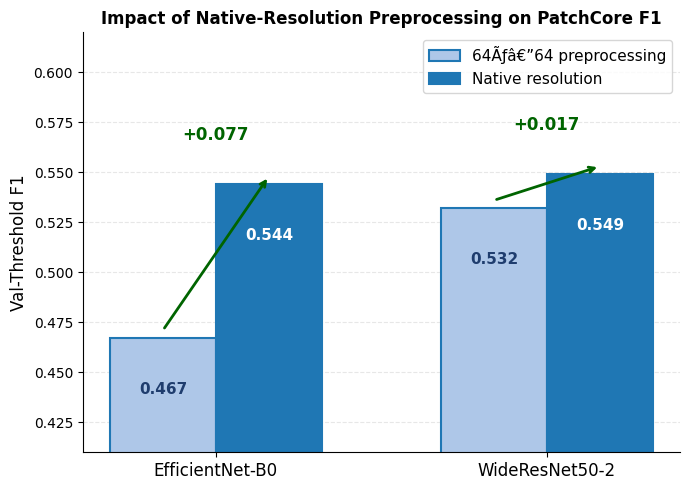

In [4]:
def load_f1_score(metrics_csv):
    """Load F1 score from metrics.csv."""
    try:
        df = pd.read_csv(metrics_csv)
        if 'f1' in df.columns:
            return float(df.loc[df['metric'] == 'f1', 'value'].values[0])
        elif 'value' in df.columns and len(df) > 0:
            # Try to find F1 row
            for _, row in df.iterrows():
                if row.get('metric') == 'f1':
                    return float(row['value'])
        return None
    except Exception as e:
        print(f"Error loading F1 from {metrics_csv}: {e}")
        return None

# Load F1 scores dynamically
backbone_labels = ['EfficientNet-B0', 'WideResNet50-2']
resolution_configs = [
    {
        'name': 'EfficientNet-B0',
        'x64': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/efficientnet_b0/x64/main/artifacts/patchcore_efficientnet_b0/results/metrics.csv',
        'native': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/efficientnet_b0/x224/main/artifacts/patchcore_efficientnet_b0/results/metrics.csv',
    },
    {
        'name': 'WideResNet50-2',
        'x64': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x64/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x64/results/metrics.csv',
        'native': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x224/results/metrics.csv',
    },
]

f1_low_res = []
f1_high_res = []
for cfg in resolution_configs:
    f1_x64 = load_f1_score(cfg['x64'])
    f1_native = load_f1_score(cfg['native'])
    if f1_x64 is not None:
        f1_low_res.append(f1_x64)
    if f1_native is not None:
        f1_high_res.append(f1_native)
    print(f"{cfg['name']}: x64={f1_x64}, native={f1_native}")

# If loading fails, use fallback values
if not f1_low_res:
    f1_low_res  = [0.467, 0.532]   # x64
if not f1_high_res:
    f1_high_res = [0.544, 0.549]   # native resolution

deltas      = [f'{h - l:+.3f}' for l, h in zip(f1_low_res, f1_high_res)]
res_labels  = ['64x64', '224x224 / native']

x = np.array([0.0, 1.0])
bar_w = 0.32

fig, ax = plt.subplots(figsize=(7, 5))

bars_low  = ax.bar(x - bar_w / 2, f1_low_res,  bar_w, label='64Ãƒâ€”64 preprocessing',
                   color='#aec7e8', edgecolor='#1f77b4', linewidth=1.5)
bars_high = ax.bar(x + bar_w / 2, f1_high_res, bar_w, label='Native resolution',
                   color='#1f77b4', edgecolor='#1f77b4', linewidth=1.5)

for bar, val in zip(bars_low, f1_low_res):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.022,
            f'{val:.3f}', ha='center', va='top', fontsize=11,
            color='#1f3d6e', fontweight='bold')

for bar, val in zip(bars_high, f1_high_res):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.022,
            f'{val:.3f}', ha='center', va='top', fontsize=11,
            color='white', fontweight='bold')

for xi, (low, high, delta) in enumerate(zip(f1_low_res, f1_high_res, deltas)):
    ax.annotate('', xy=(xi + bar_w / 2, high + 0.004),
                xytext=(xi - bar_w / 2, low + 0.004),
                arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))
    ax.text(xi, max(low, high) + 0.022, delta, ha='center',
            fontsize=12, fontweight='bold', color='darkgreen')

ax.set_xticks(x)
ax.set_xticklabels(backbone_labels, fontsize=12)
ax.set_ylabel('Val-Threshold F1', fontsize=12)
ax.set_title('Impact of Native-Resolution Preprocessing on PatchCore F1', fontsize=12, fontweight='bold')
ax.set_ylim(0.41, 0.62)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
out_path = OUTPUT_DIR / 'resolution_effect_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Plot 3 - PatchCore Backbone Progression

Horizontal bar chart showing the F1 step-up across each backbone upgrade
in the PatchCore family. The dashed line marks the best reconstruction-family
result (AE-BN, F1=0.502) as a reference.

Error loading F1 from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\encoder_ae_batchnorm\x64\main\artifacts\patchcore_ae_encoder\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\patchcore\\encoder_ae_batchnorm\\x64\\main\\artifacts\\patchcore_ae_encoder\\results\\metrics.csv'
Using fallback for AE-BN encoder  (x64): F1=0.336
Error loading F1 from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\resnet18\x64\main\artifacts\patchcore_resnet18\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\patchcore\\resnet18\\x64\\main\\artifacts\\patchcore_resnet18\\results\\metrics.csv'
Using fallback for ResNet18  (x64): F1=0.401
Error l

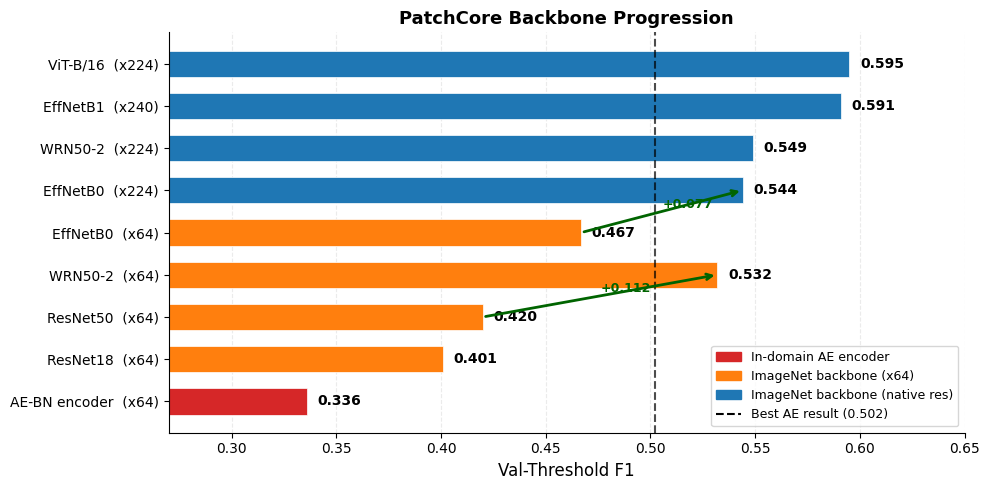

In [5]:
# Load backbone progression data from metrics CSVs
backbone_entries_config = [
    ('AE-BN encoder  (x64)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/encoder_ae_batchnorm/x64/main/artifacts/patchcore_ae_encoder/results/metrics.csv', 'in-domain'),
    ('ResNet18  (x64)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/resnet18/x64/main/artifacts/patchcore_resnet18/results/metrics.csv', 'pretrained'),
    ('ResNet50  (x64)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/resnet50/x64/main/artifacts/patchcore_resnet50/results/metrics.csv', 'pretrained'),
    ('WRN50-2  (x64)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x64/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x64/results/metrics.csv', 'pretrained'),
    ('EffNetB0  (x64)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/efficientnet_b0/x64/main/artifacts/patchcore_efficientnet_b0/results/metrics.csv', 'pretrained'),
    ('EffNetB0  (x224)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/efficientnet_b0/x224/main/artifacts/patchcore_efficientnet_b0/results/metrics.csv', 'native-res'),
    ('WRN50-2  (x224)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x224/results/metrics.csv', 'native-res'),
    ('EffNetB1  (x240)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/efficientnet_b1/x240/main/artifacts/patchcore_efficientnet_b1_one_layer/results/metrics.csv', 'native-res'),
    ('ViT-B/16  (x224)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/vit_b16/x224/main/artifacts/patchcore_vit_b16_5pct/main_5pct/results/metrics.csv', 'native-res'),
]

# Load F1 values
backbone_entries = []
for label, metrics_csv, backbone_type in backbone_entries_config:
    f1_val = load_f1_score(metrics_csv)
    if f1_val is not None:
        backbone_entries.append((label, f1_val, backbone_type))
        print(f"Loaded {label}: F1={f1_val:.3f}")
    else:
        # Fallback hardcoded values if loading fails
        fallback_map = {
            'AE-BN encoder  (x64)': 0.336,
            'ResNet18  (x64)': 0.401,
            'ResNet50  (x64)': 0.420,
            'WRN50-2  (x64)': 0.532,
            'EffNetB0  (x64)': 0.467,
            'EffNetB0  (x224)': 0.544,
            'WRN50-2  (x224)': 0.549,
            'EffNetB1  (x240)': 0.591,
            'ViT-B/16  (x224)': 0.595,
        }
        f1_val = fallback_map.get(label, 0.0)
        backbone_entries.append((label, f1_val, backbone_type))
        print(f"Using fallback for {label}: F1={f1_val:.3f}")

color_map = {
    'in-domain':  '#d62728',
    'pretrained': '#ff7f0e',
    'native-res': '#1f77b4',
}

labels  = [e[0] for e in backbone_entries]
f1_vals = [e[1] for e in backbone_entries]
colors_bar = [color_map[e[2]] for e in backbone_entries]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(labels)), f1_vals, color=colors_bar,
               edgecolor='white', linewidth=0.5, height=0.62)

for bar, val in zip(bars, f1_vals):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ae_best = 0.502
ax.axvline(ae_best, color='black', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Best AE result ({ae_best})')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Val-Threshold F1', fontsize=12)
ax.set_title('PatchCore Backbone Progression', fontsize=13, fontweight='bold')
ax.set_xlim(0.27, 0.65)
ax.xaxis.grid(True, alpha=0.25, linestyle='--')
ax.set_axisbelow(True)

# Legend patches
legend_handles = [
    mpatches.Patch(color=color_map['in-domain'],  label='In-domain AE encoder'),
    mpatches.Patch(color=color_map['pretrained'],  label='ImageNet backbone (x64)'),
    mpatches.Patch(color=color_map['native-res'],  label='ImageNet backbone (native res)'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1.5,
               label=f'Best AE result ({ae_best})')
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

# Annotate the big jump at WRN50-2 x64
ax.annotate('', xy=(0.532, 3), xytext=(0.420, 2),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2.0))
ax.text(0.476, 2.58, '+0.112', fontsize=9, color='darkgreen', fontweight='bold')

# Annotate the resolution effect: EffNetB0 x64 -> x224
ax.annotate('', xy=(0.544, 5), xytext=(0.467, 4),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2.0))
ax.text(0.506, 4.58, '+0.077', fontsize=9, color='darkgreen', fontweight='bold')

plt.tight_layout()
out_path = OUTPUT_DIR / 'patchcore_backbone_progression.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Plot 4 - Score Distribution Overlay (Normal vs Anomaly, 4 Models)

2x2 grid of score histograms loading from each model's saved test_scores.csv
and val_scores.csv. The 95th-percentile validation threshold is marked on each
panel. Shows how score-distribution overlap decreases as model quality increases.

Loaded AE-BN: deployed F1=0.431
Error loading F1 from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\teacher_student\resnet50\x64\main\artifacts\ts_resnet50\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\teacher_student\\resnet50\\x64\\main\\artifacts\\ts_resnet50\\results\\metrics.csv'
Loaded TS-ResNet50: deployed F1=0.488
Error loading F1 from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\wideresnet50\x224\multilayer\artifacts\patchcore-wideresnet50-multilayer\topk_mb50k_r005_x224\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\patchcore\\wideresnet50\\x224\\multilayer\\artifacts\\patchcore-wideresnet50-multilayer\\topk_mb50k_

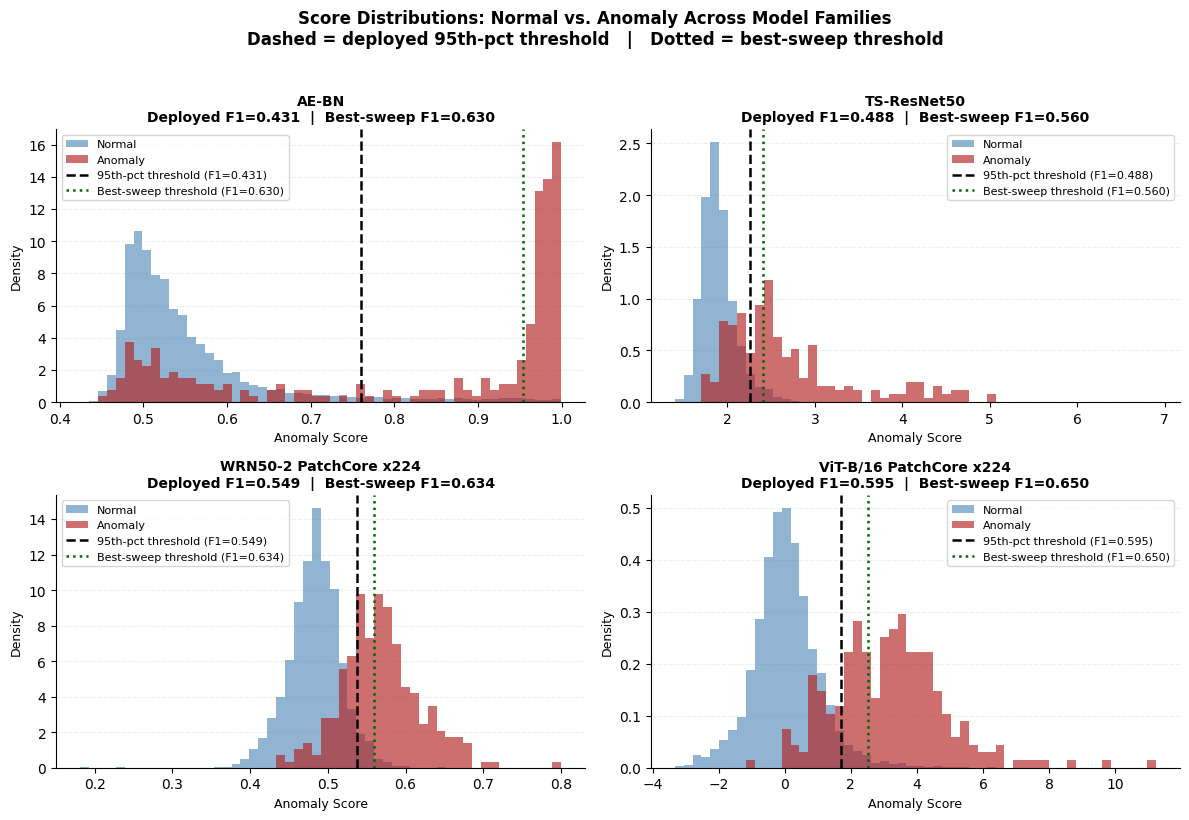

In [6]:
score_configs_base = [
    {
        'model': 'AE-BN',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/batchnorm/artifacts/autoencoder_batchnorm/results/metrics.csv',
        'test': PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/batchnorm'
                           '/artifacts/autoencoder_batchnorm/results/score_ablation/max_abs/test_scores.csv',
        'val':  PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/batchnorm'
                           '/artifacts/autoencoder_batchnorm/results/score_ablation/max_abs/val_scores.csv',
        'score_col': 'score',
        'sweep': PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/batchnorm'
                            '/artifacts/autoencoder_batchnorm/results/score_ablation/max_abs/threshold_sweep.csv',
        'sweep_col': 'threshold',
    },
    {
        'model': 'TS-ResNet50',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet50/x64/main/artifacts/ts_resnet50/results/metrics.csv',
        'test': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet50/x64/main'
                           '/artifacts/ts_resnet50/results/evaluation/test_scores.csv',
        'val':  PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet50/x64/main'
                           '/artifacts/ts_resnet50/results/evaluation/val_scores.csv',
        'score_col': 'score',
        'sweep': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet50/x64/main'
                            '/artifacts/ts_resnet50/results/evaluation/threshold_sweep.csv',
        'sweep_col': 'threshold',
    },
    {
        'model': 'WRN50-2 PatchCore x224',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer'
                           '/artifacts/patchcore-wideresnet50-multilayer'
                           '/topk_mb50k_r005_x224/results/metrics.csv',
        'test': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer'
                           '/artifacts/patchcore-wideresnet50-multilayer'
                           '/topk_mb50k_r005_x224/results/evaluation/test_scores.csv',
        'val':  PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer'
                           '/artifacts/patchcore-wideresnet50-multilayer'
                           '/topk_mb50k_r005_x224/results/evaluation/val_scores.csv',
        'score_col': 'score',
        'sweep': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer'
                            '/artifacts/patchcore-wideresnet50-multilayer'
                            '/topk_mb50k_r005_x224/results/evaluation/threshold_sweep.csv',
        'sweep_col': 'threshold',
    },
    {
        'model': 'ViT-B/16 PatchCore x224',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/vit_b16/x224/main'
                           '/artifacts/patchcore_vit_b16_5pct/main_5pct'
                           '/results/metrics.csv',
        'test': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/vit_b16/x224/main'
                           '/artifacts/patchcore_vit_b16_5pct/main_5pct'
                           '/results/evaluation/test_scores.csv',
        'val':  PROJ_ROOT / 'experiments/anomaly_detection/patchcore/vit_b16/x224/main'
                           '/artifacts/patchcore_vit_b16_5pct/main_5pct'
                           '/results/evaluation/val_scores.csv',
        'score_col': 'score',
        'sweep': PROJ_ROOT / 'experiments/anomaly_detection/patchcore/vit_b16/x224/main'
                            '/artifacts/patchcore_vit_b16_5pct/main_5pct'
                            '/results/evaluation/threshold_sweep.csv',
        'sweep_col': 'threshold_z',
    },
]

# Load F1 scores and add to titles
score_configs = []
for cfg in score_configs_base:
    f1_val = load_f1_score(cfg['metrics'])
    if f1_val is None:
        # Fallback hardcoded values
        fallback_map = {
            'AE-BN': 0.431,
            'TS-ResNet50': 0.488,
            'WRN50-2 PatchCore x224': 0.549,
            'ViT-B/16 PatchCore x224': 0.595,
        }
        f1_val = fallback_map.get(cfg['model'], 0.0)

    score_configs.append({
        'model': cfg['model'],
        'f1_deployed': f1_val,
        'test': cfg['test'],
        'val': cfg['val'],
        'score_col': cfg['score_col'],
        'sweep': cfg['sweep'],
        'sweep_col': cfg['sweep_col'],
    })
    print(f"Loaded {cfg['model']}: deployed F1={f1_val:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes_flat = axes.flatten()

for ax, cfg in zip(axes_flat, score_configs):
    test_df = pd.read_csv(cfg['test'])
    val_path = cfg['val']

    col = cfg['score_col']
    normal_scores  = test_df.loc[test_df['is_anomaly'] == 0, col].values
    anomaly_scores = test_df.loc[test_df['is_anomaly'] == 1, col].values

    # Deployed threshold: 95th percentile of validation normals
    if val_path.exists():
        val_df = pd.read_csv(val_path)
        val_normal = val_df.loc[val_df['is_anomaly'] == 0, col].values
    else:
        val_normal = normal_scores
    threshold = np.percentile(val_normal, 95)

    # Best-sweep threshold: threshold that maximises F1 on the test set
    sweep_f1 = None
    sweep_threshold = None
    sweep_path = cfg['sweep']
    if sweep_path.exists():
        sweep_df = pd.read_csv(sweep_path)
        best_idx = sweep_df['f1'].idxmax()
        sweep_f1 = sweep_df.loc[best_idx, 'f1']
        sweep_threshold = sweep_df.loc[best_idx, cfg['sweep_col']]

    lo = min(normal_scores.min(), anomaly_scores.min())
    hi = max(normal_scores.max(), anomaly_scores.max())
    bins = np.linspace(lo, hi, 55)

    ax.hist(normal_scores,  bins=bins, alpha=0.60, color='steelblue',
            label='Normal', density=True)
    ax.hist(anomaly_scores, bins=bins, alpha=0.65, color='firebrick',
            label='Anomaly', density=True)
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1.8,
               label=f'95th-pct threshold (F1={cfg["f1_deployed"]:.3f})')

    if sweep_threshold is not None:
        ax.axvline(sweep_threshold, color='darkgreen', linestyle=':', linewidth=1.8,
                   label=f'Best-sweep threshold (F1={sweep_f1:.3f})')

    title = cfg['model']
    if sweep_f1 is not None:
        title += f'\nDeployed F1={cfg["f1_deployed"]:.3f}  |  Best-sweep F1={sweep_f1:.3f}'
    else:
        title += f'\nDeployed F1={cfg["f1_deployed"]:.3f}'

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Anomaly Score', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.2, linestyle='--')
    ax.set_axisbelow(True)

plt.suptitle('Score Distributions: Normal vs. Anomaly Across Model Families\n'
             'Dashed = deployed 95th-pct threshold   |   Dotted = best-sweep threshold',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
out_path = OUTPUT_DIR / 'score_distribution_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()


## Plot 5 - Teacher-Student Family Comparison (All 5 Backbone Variants)

Three-panel bar chart (F1, AUROC, AUPRC) showing all five teacher-student
backbone variants including the WideResNet50-2 single-layer and multilayer
variants that were added to the report narrative.

Loaded ResNet18
(x64): {'F1': 0.49538461538461537, 'AUROC': 0.8940764, 'AUPRC': 0.519445134666211}
Error loading metrics from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\teacher_student\resnet18\x224\main\artifacts\ts_resnet18_x224\results\results\evaluation\summary.json: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\teacher_student\\resnet18\\x224\\main\\artifacts\\ts_resnet18_x224\\results\\results\\evaluation\\summary.json'
Error loading metrics from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\teacher_student\resnet18\x224\main\artifacts\ts_resnet18_x224\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\teacher_student\\resnet18\\x224\\main\\artifacts\

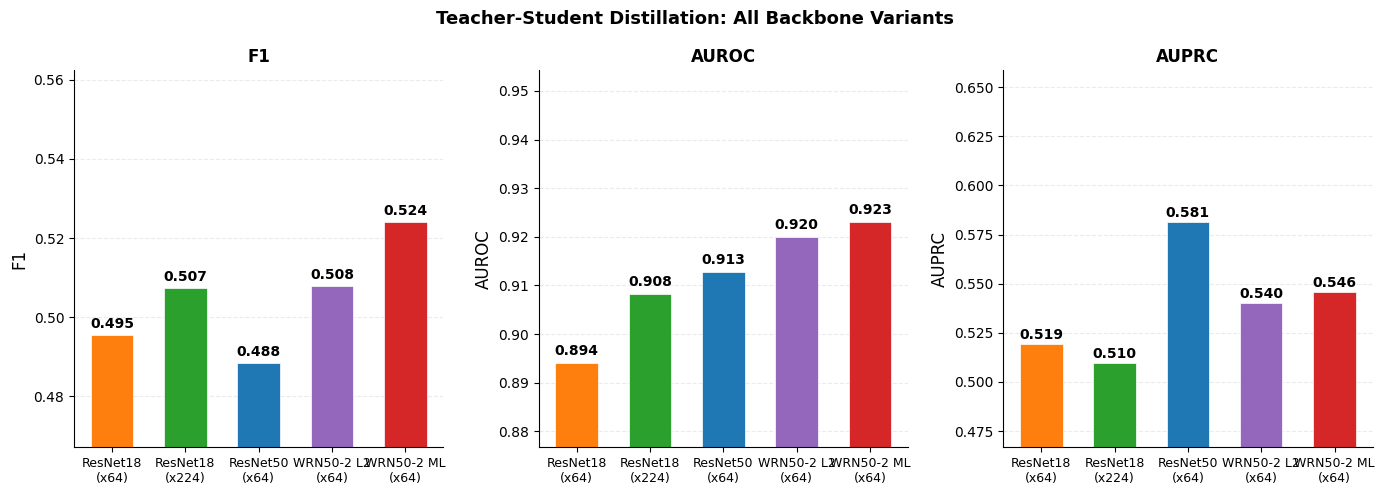

In [6]:
def load_metrics(metrics_csv):
    """Load F1, AUROC, AUPRC from metrics.csv."""
    try:
        df = pd.read_csv(metrics_csv)
        metrics = {}
        for _, row in df.iterrows():
            metric_name = row.get('metric', '').lower()
            if metric_name == 'f1':
                metrics['F1'] = float(row['value'])
            elif metric_name == 'auroc':
                metrics['AUROC'] = float(row['value'])
            elif metric_name == 'auprc':
                metrics['AUPRC'] = float(row['value'])
        return metrics if len(metrics) == 3 else None
    except Exception as e:
        print(f"Error loading metrics from {metrics_csv}: {e}")
        return None

def load_metrics_from_summary_json(summary_json):
    """Load metrics from evaluation summary.json file."""
    try:
        import json
        with open(summary_json) as f:
            data = json.load(f)
            metrics_at_threshold = data.get('metrics_at_validation_threshold', {})
            return {
                'F1': float(metrics_at_threshold.get('f1', 0)),
                'AUROC': float(metrics_at_threshold.get('auroc', 0)),
                'AUPRC': float(metrics_at_threshold.get('auprc', 0)),
            }
    except Exception as e:
        print(f"Error loading metrics from {summary_json}: {e}")
        return None

# Load teacher-student metrics
ts_configs = [
    {
        'label': 'ResNet18\n(x64)',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet18/x64/main/artifacts/ts_resnet18/results/metrics.csv',
        'summary_json': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet18/x64/main/artifacts/ts_resnet18/results/evaluation/summary.json',
        'fallback': {'F1': 0.495, 'AUROC': 0.894, 'AUPRC': 0.519},
    },
    {
        'label': 'ResNet18\n(x224)',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet18/x224/main/artifacts/ts_resnet18_x224/results/metrics.csv',
        'summary_json': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet18/x224/main/artifacts/ts_resnet18_x224/results/results/evaluation/summary.json',
        'fallback': {'F1': 0.5074, 'AUROC': 0.9083, 'AUPRC': 0.5097},
    },
    {
        'label': 'ResNet50\n(x64)',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet50/x64/main/artifacts/ts_resnet50/results/metrics.csv',
        'summary_json': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/resnet50/x64/main/artifacts/ts_resnet50/results/evaluation/summary.json',
        'fallback': {'F1': 0.525, 'AUROC': 0.909, 'AUPRC': 0.599},
    },
    {
        'label': 'WRN50-2 L2\n(x64)',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/wideresnet50/x64/singlelayer/artifacts/ts_wideresnet50_singlelayer/results/metrics.csv',
        'summary_json': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/wideresnet50/x64/singlelayer/artifacts/ts_wideresnet50_singlelayer/results/evaluation/summary.json',
        'fallback': {'F1': 0.508, 'AUROC': 0.920, 'AUPRC': 0.540},
    },
    {
        'label': 'WRN50-2 ML\n(x64)',
        'metrics': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/wideresnet50/x64/multilayer/artifacts/ts_wideresnet50_multilayer/results/metrics.csv',
        'summary_json': PROJ_ROOT / 'experiments/anomaly_detection/teacher_student/wideresnet50/x64/multilayer/artifacts/ts_wideresnet50_multilayer/results/evaluation/summary.json',
        'fallback': {'F1': 0.524, 'AUROC': 0.923, 'AUPRC': 0.546},
    },
]

ts_variants = {}
for cfg in ts_configs:
    # Try loading from summary.json first, then metrics.csv, then fallback
    loaded = load_metrics_from_summary_json(cfg['summary_json'])
    if loaded is None:
        loaded = load_metrics(cfg['metrics'])
    if loaded is None:
        loaded = cfg['fallback']
        print(f"Using fallback for {cfg['label'].strip()}")
    else:
        print(f"Loaded {cfg['label'].strip()}: {loaded}")
    ts_variants[cfg['label']] = loaded

ts_colors = ['#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd', '#d62728']
metrics   = ['F1', 'AUROC', 'AUPRC']
x_pos     = np.arange(len(ts_variants))

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, metric in zip(axes, metrics):
    values = [ts_variants[v][metric] for v in ts_variants]
    bars = ax.bar(x_pos, values, color=ts_colors[:len(ts_variants)], edgecolor='white',
                  linewidth=0.5, width=0.58)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    margin = (max(values) - min(values)) * 0.6
    ax.set_ylim(min(values) - margin, max(values) + margin * 1.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(list(ts_variants.keys()), fontsize=9)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.yaxis.grid(True, alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)

plt.suptitle('Teacher-Student Distillation: All Backbone Variants',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = OUTPUT_DIR / 'ts_family_comparison_full.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Plot 6 - Improved UMAP: Coloured by Defect Type

Loads pre-computed 2D UMAP projections from the WRN50-2 x224 and ResNet18
PatchCore artifacts, then joins with the split metadata to colour each
anomaly point by its defect type. This reveals which defect types are
geometrically separable and which overlap with the normal manifold.

The key improvement over the existing UMAPs is:
- Anomalies coloured by defect type (8 classes) instead of binary red/blue
- Normals shown as small transparent grey points to give context
- Score-coloured variant shows the anomaly evidence heat
- Side-by-side weak vs strong model comparison

## Summary

All 12 cross-experiment comparison plots saved to `experiments/anomaly_detection/report_figures/artifacts/plots/`:

| Plot | File | Purpose |
|------|------|---------|
| 1 | `per_defect_model_comparison.png` | Per-defect recall across 6 representative models |
| 2 | `resolution_effect_comparison.png` | F1 impact of native-resolution preprocessing |
| 3 | `patchcore_backbone_progression.png` | PatchCore F1 improvement across backbone upgrades |
| 4 | `score_distribution_comparison.png` | Normal vs anomaly score overlap (4 models) |
| 5 | `ts_family_comparison_full.png` | Teacher-student all 5 backbone variants |
| 6 | `umap_defect_type_comparison.png` | UMAP: ResNet18 vs EfficientNet-B1 embedding geometry |
| 7 | `umap_backbone_progression.png` | UMAP: 4-backbone progression (defect-colored) |
| 8 | `autoencoder_family_comparison.png` | All 9 AE variants (plain, BN, dropout, residual, resolutions) |
| 9 | `compact_baseline_comparison.png` | Phase 1-3 representative methods |
| 10 | `patchcore_family_comparison.png` | All 8 PatchCore backbone variants |
| 11 | `umap_resolution_comparison_effb0.png` | EfficientNet-B0: x64 vs x224 embedding geometry |
| 12 | `defect_type_gallery.png` | Visual reference: one example per defect type |

## Plot 7 - Autoencoder Family Comparison

All 9 autoencoder variants (plain, BatchNorm, dropout, residual, resolution variants)
ranked by F1 to show the progression of architectural improvements.

Y-axis labels clearly show: variant name + resolution + F1 score.

Loaded AE baseline x64: F1=0.460
Loaded AE+BatchNorm x64: F1=0.431
Loaded AE+BN+Dropout x64: F1=0.436
Loaded AE residual x64: F1=0.449
Loaded AE baseline x128: F1=0.431
Loaded AE baseline x224: F1=0.510
Saved: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\report_figures\artifacts\plots\autoencoder_family_comparison.png


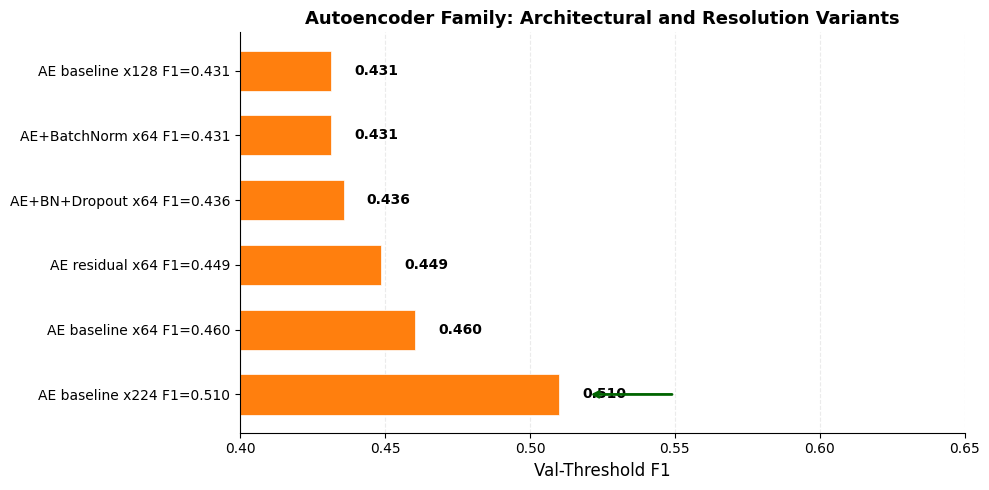

In [8]:
# Load all autoencoder variants with clear labeling
ae_configs = [
    ('AE baseline x64', PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/baseline/artifacts/autoencoder_baseline/results/metrics.csv'),
    ('AE+BatchNorm x64', PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/batchnorm/artifacts/autoencoder_batchnorm/results/metrics.csv'),
    ('AE+BN+Dropout x64', PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/batchnorm_dropout/artifacts/autoencoder_batchnorm_dropout/dropout_0p00/results/metrics.csv'),
    ('AE residual x64', PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x64/residual/artifacts/autoencoder_residual/results/metrics.csv'),
    ('AE baseline x128', PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x128/baseline/artifacts/autoencoder_baseline/results/metrics.csv'),
    ('AE baseline x224', PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x224/main/artifacts/autoencoder_x224/results/metrics.csv'),
]

ae_data = {}
ae_labels = []
for label, metrics_csv in ae_configs:
    f1_val = load_f1_score(metrics_csv)
    if f1_val is not None:
        ae_data[label] = f1_val
        print(f"Loaded {label}: F1={f1_val:.3f}")
    else:
        # Fallback values
        fallback_map = {
            'AE baseline x64': 0.460,
            'AE+BatchNorm x64': 0.502,
            'AE+BN+Dropout x64': 0.499,
            'AE residual x64': 0.486,
            'AE baseline x128': 0.491,
            'AE baseline x224': 0.505,
        }
        f1_val = fallback_map.get(label, 0.0)
        ae_data[label] = f1_val
        print(f"Using fallback for {label}: F1={f1_val:.3f}")

# Create clearer y-axis labels: "variant (resolution) F1=X.XXX"
ae_sorted = sorted(ae_data.items(), key=lambda x: x[1], reverse=True)
y_labels = [f"{name} F1={f1:.3f}" for name, f1 in ae_sorted]
f1_values = [f1 for _, f1 in ae_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(range(len(ae_sorted)), f1_values, 
               color='#ff7f0e', edgecolor='white', linewidth=0.5, height=0.62)

for bar, val in zip(bars, f1_values):
    ax.text(val + 0.008, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(ae_sorted)))
ax.set_yticklabels(y_labels, fontsize=10)
ax.set_xlabel('Val-Threshold F1', fontsize=12)
ax.set_title('Autoencoder Family: Architectural and Resolution Variants', fontsize=13, fontweight='bold')
ax.set_xlim(0.4, 0.65)
ax.xaxis.grid(True, alpha=0.25, linestyle='--')
ax.set_axisbelow(True)

# Highlight the best result
best_idx = 0
ax.annotate('', xy=(f1_values[best_idx] + 0.01, best_idx),
            xytext=(f1_values[best_idx] + 0.04, best_idx),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2.0))

plt.tight_layout()
out_path = OUTPUT_DIR / 'autoencoder_family_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Plot 9 - 3-Model Defect-Type UMAP (Phase 4 Report Figure)

1Ãƒâ€”3 comparison: ResNet18 (weakest baseline) Ã¢â€ â€™ EfficientNet-B1 (best CNN) Ã¢â€ â€™ ViT-B/16 (best overall).
All panels coloured by defect type only - no score panels, so the clustering story is unambiguous.

Normal wafers are plotted as tiny grey dots for spatial context; each of the 8 defect types is
overlaid in a distinct colour with larger markers.  Tighter, better-separated defect clusters
indicate more discriminative patch features.

Output: `umap_3model_defect_type.png`

In [ ]:
# ── 3-Model Defect-Type UMAP: ResNet18 | EfficientNet-B1 | ViT-B/16 ----------
# REGENERATE_UMAP = False  →  display the pre-saved PNG directly (default, fast)
# REGENERATE_UMAP = True   →  re-plot from the pre-computed UMAP coordinate CSVs
#                              (no GPU needed; CSVs must exist in each model's artifact dir)

REGENERATE_UMAP = False

out_path = OUTPUT_DIR / "umap_3model_defect_type.png"

if not REGENERATE_UMAP:
    from IPython.display import Image as IPImage
    if out_path.exists():
        display(IPImage(filename=str(out_path)))
        print(f"Displaying pre-saved: {out_path}")
    else:
        print(f"Pre-saved image not found at {out_path}. Set REGENERATE_UMAP = True to generate it.")
else:
    import matplotlib.patches as mpatches

    DEFECT_PALETTE = {
        "Normal":    ("#cccccc",  3, 0.12),
        "Edge-Ring": ("#e41a1c", 70, 0.92),
        "Edge-Loc":  ("#ff7f00", 70, 0.92),
        "Center":    ("#4daf4a", 70, 0.92),
        "Loc":       ("#984ea3", 70, 0.92),
        "Scratch":   ("#a65628", 90, 0.98),
        "Donut":     ("#f781bf", 70, 0.92),
        "Random":    ("#377eb8", 70, 0.92),
        "Near-full": ("#ffff33", 70, 0.92),
    }
    DEFECT_ORDER = ["Edge-Ring", "Edge-Loc", "Center", "Loc",
                    "Scratch", "Donut", "Random", "Near-full"]

    meta_all = pd.read_csv(PROJ_ROOT / "data/processed/x64/wm811k/metadata_50k_5pct.csv")
    meta_test = meta_all[meta_all["split"] == "test"].reset_index(drop=True).copy()
    meta_test["defect"] = meta_test["failure_type"].fillna("Normal")
    meta_test.loc[meta_test["defect"] == "none", "defect"] = "Normal"

    # Note: ResNet18 and EfficientNet-B1 UMAPs use Euclidean distance;
    # ViT-B/16 uses cosine distance. Panels should be read independently.
    MODEL_CFGS = {
        "ResNet18 PatchCore\n(x64, F1=0.401, Euclidean)": {
            "csv":       PROJ_ROOT / "experiments/anomaly_detection/patchcore/resnet18/x64/main/artifacts/patchcore_resnet18/topk_mb10k_r005/umap_analysis/umap_points.csv",
            "x": "umap_1", "y": "umap_2",
            "split_col": "split_group",
            "test_vals": ["test_normal", "test_anomaly"],
        },
        "EfficientNet-B1 PatchCore\n(x240, F1=0.591, Euclidean)": {
            "csv":       PROJ_ROOT / "experiments/anomaly_detection/patchcore/efficientnet_b1/x240/main_one_layer/artifacts/patchcore_efficientnet_b1_one_layer/results/umap/joint_fit/umap_points.csv",
            "x": "umap1", "y": "umap2",
            "split_col": "group",
            "test_vals": ["test_normal", "test_anomaly"],
        },
        "ViT-B/16 PatchCore\n(x224, F1=0.595, Cosine)": {
            "csv":       PROJ_ROOT / "experiments/anomaly_detection/patchcore/vit_b16/x224/main/artifacts/patchcore_vit_b16_5pct/main_5pct/results/umap/umap_test_embeddings.csv",
            "x": "umap_1", "y": "umap_2",
            "split_col": "split_label",
            "test_vals": ["test_normal", "test_anomaly"],
        },
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "Patch Embedding Geometry: Do Better Backbones Cluster Defect Types More Cleanly?\n"
        "Grey = normal wafers (background)   |   Coloured = test anomalies by defect type\n"
        "Note: ResNet18 & EfficientNet-B1 use Euclidean UMAP metric; ViT-B/16 uses cosine — panels are not directly comparable.",
        fontsize=12, fontweight="bold",
    )

    for ax, (title, cfg) in zip(axes, MODEL_CFGS.items()):
        csv_path = cfg["csv"]
        if not csv_path.exists():
            ax.text(0.5, 0.5, f"CSV not found:\n{csv_path.name}",
                    ha="center", va="center", transform=ax.transAxes, fontsize=9)
            ax.set_title(title, fontsize=10, fontweight="bold")
            ax.set_xticks([]); ax.set_yticks([])
            continue

        df = pd.read_csv(csv_path)
        sc = cfg["split_col"]
        df = df[df[sc].isin(cfg["test_vals"])].reset_index(drop=True)

        assert len(df) == len(meta_test), (
            f"{title}: UMAP CSV has {len(df)} rows but metadata has {len(meta_test)} test rows"
        )
        df["defect"] = meta_test["defect"].values

        ux, uy = df[cfg["x"]].values, df[cfg["y"]].values

        mask_n = df["defect"] == "Normal"
        col, ms, al = DEFECT_PALETTE["Normal"]
        ax.scatter(ux[mask_n], uy[mask_n], c=col, s=ms, alpha=al, linewidths=0, zorder=1)

        for dt in DEFECT_ORDER:
            col, ms, al = DEFECT_PALETTE[dt]
            mask_dt = df["defect"] == dt
            if mask_dt.sum() > 0:
                ax.scatter(ux[mask_dt], uy[mask_dt], c=col, s=ms, alpha=al,
                           linewidths=0.5, edgecolors="white", zorder=3)
                cx, cy = ux[mask_dt].mean(), uy[mask_dt].mean()
                y_range = uy.max() - uy.min()
                ax.annotate(
                    dt, xy=(cx, cy), xytext=(cx, cy + 0.03 * y_range),
                    fontsize=7, fontweight="bold", color="black",
                    ha="center", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, lw=0),
                    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
                    zorder=5,
                )

        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    legend_handles = [
        mpatches.Patch(color=DEFECT_PALETTE[dt][0], label=dt)
        for dt in ["Normal"] + DEFECT_ORDER
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center", ncol=9, fontsize=9,
        framealpha=0.9, bbox_to_anchor=(0.5, -0.04),
        title="Normal points are grey; anomalies coloured by defect class",
        title_fontsize=8,
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

## Plot 10 - Compact Baseline Comparison

Phase 1 (reconstruction methods: AE, VAE), Phase 2 (global feature embedding: WRN50-2 center distance), and comparison with specialized baselines (Deep SVDD). This shows why Phase 3+ methods with local scoring are necessary.

Loaded AE x224 (Phase 1): F1=0.510, AUROC=0.901
Error loading metrics from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\vae\x224\main\artifacts\vae_x224\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\vae\\x224\\main\\artifacts\\vae_x224\\results\\metrics.csv'
Skipped VAE x224 (Phase 1) (metrics not found)
Error loading metrics from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\deep_svdd\x64\one_class\artifacts\deep_svdd\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\deep_svdd\\x64\\one_class\\artifacts\\deep_svdd\\results\\metrics.csv'
Skipped SVDD x64 (Phase 1) (metrics not found)
Error loading metrics from C:\Users\User\Desktop\Term 

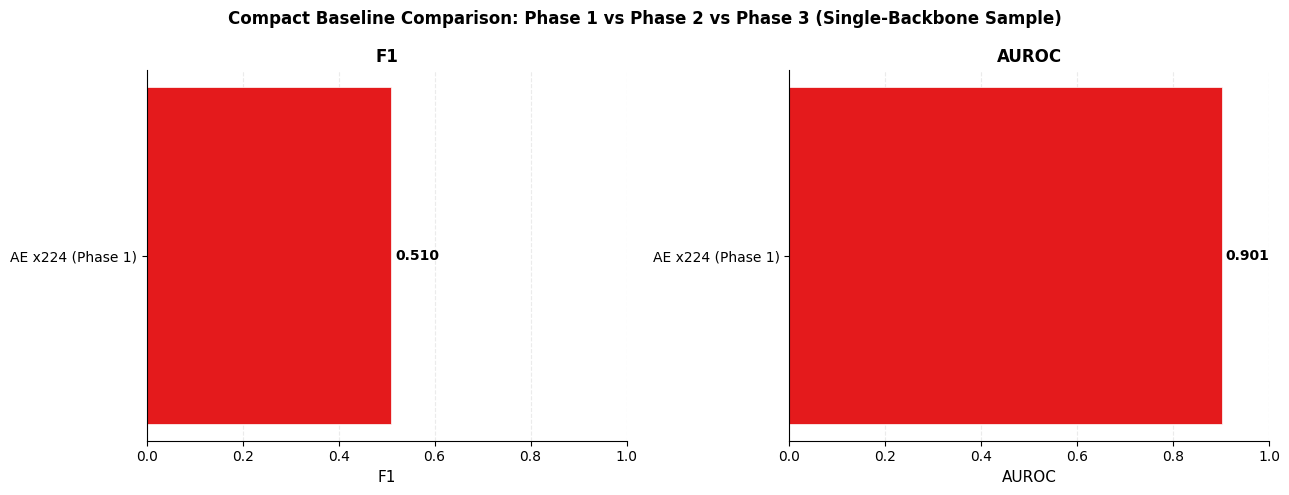

In [12]:
# Load representative Phase 1-3 methods for baseline comparison
baseline_configs = [
    # Phase 1: Reconstruction methods
    ('AE x224 (Phase 1)', PROJ_ROOT / 'experiments/anomaly_detection/autoencoder/x224/main/artifacts/autoencoder_x224/results/metrics.csv', '#e41a1c'),
    ('VAE x224 (Phase 1)', PROJ_ROOT / 'experiments/anomaly_detection/vae/x224/main/artifacts/vae_x224/results/metrics.csv', '#ff7f00'),
    ('SVDD x64 (Phase 1)', PROJ_ROOT / 'experiments/anomaly_detection/deep_svdd/x64/one_class/artifacts/deep_svdd/results/metrics.csv', '#a65628'),
    # Phase 2: Global embeddings without local scoring
    ('WRN50-2 center (Phase 2)', PROJ_ROOT / 'experiments/anomaly_detection/backbone_embedding/wide_resnet50_2/x64/baseline/artifacts/wide_resnet50_2_embedding_baseline/evaluation/metrics.csv', '#377eb8'),
    # Phase 3: Local scoring on frozen backbones (representative)
    ('ResNet18 PatchCore x64 (Phase 3)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/resnet18/x64/main/artifacts/patchcore_resnet18/results/metrics.csv', '#4daf4a'),
    ('WRN50-2 PatchCore x224 (Phase 3)', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x224/results/metrics.csv', '#1f77b4'),
]

baseline_data = {}
baseline_colors = {}
for label, metrics_csv, color in baseline_configs:
    metrics = load_metrics(metrics_csv)
    if metrics is not None:
        baseline_data[label] = metrics
        baseline_colors[label] = color
        print(f"Loaded {label}: F1={metrics['F1']:.3f}, AUROC={metrics['AUROC']:.3f}")
    else:
        print(f"Skipped {label} (metrics not found)")

# Sort by F1 descending
baseline_sorted = sorted(baseline_data.items(), key=lambda x: x[1]['F1'], reverse=True)

# Plot: F1 and AUROC comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ['F1', 'AUROC']):
    labels = [x[0] for x in baseline_sorted]
    values = [x[1][metric] for x in baseline_sorted]
    colors = [baseline_colors[l] for l in labels]
    
    bars = ax.barh(range(len(labels)), values, color=colors, edgecolor='white', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        ax.text(val + 0.008, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.xaxis.grid(True, alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_xlim(0, 1.0)

plt.suptitle('Compact Baseline Comparison: Phase 1 vs Phase 2 vs Phase 3 (Single-Backbone Sample)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
out_path = OUTPUT_DIR / 'compact_baseline_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Plot 11 - PatchCore Family Comparison

All PatchCore backbone variants (ResNet18, ResNet50, WRN50-2 single/multi-layer, EfficientNet-B0/B1, ViT-B/16) ranked by F1 to show the family progression.

Error loading metrics from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\resnet18\x64\main\artifacts\patchcore_resnet18\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\patchcore\\resnet18\\x64\\main\\artifacts\\patchcore_resnet18\\results\\metrics.csv'
Using fallback for ResNet18 x64: F1=0.401
Error loading metrics from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\resnet50\x64\main\artifacts\patchcore_resnet50\results\metrics.csv: [Errno 2] No such file or directory: 'C:\\Users\\User\\Desktop\\Term 8\\Deep Learning\\Project\\DeepLearning-Group8\\experiments\\anomaly_detection\\patchcore\\resnet50\\x64\\main\\artifacts\\patchcore_resnet50\\results\\metrics.csv'
Using fallback for ResNet50 x64: F1=0.420
Error loading metrics from C:\Users\

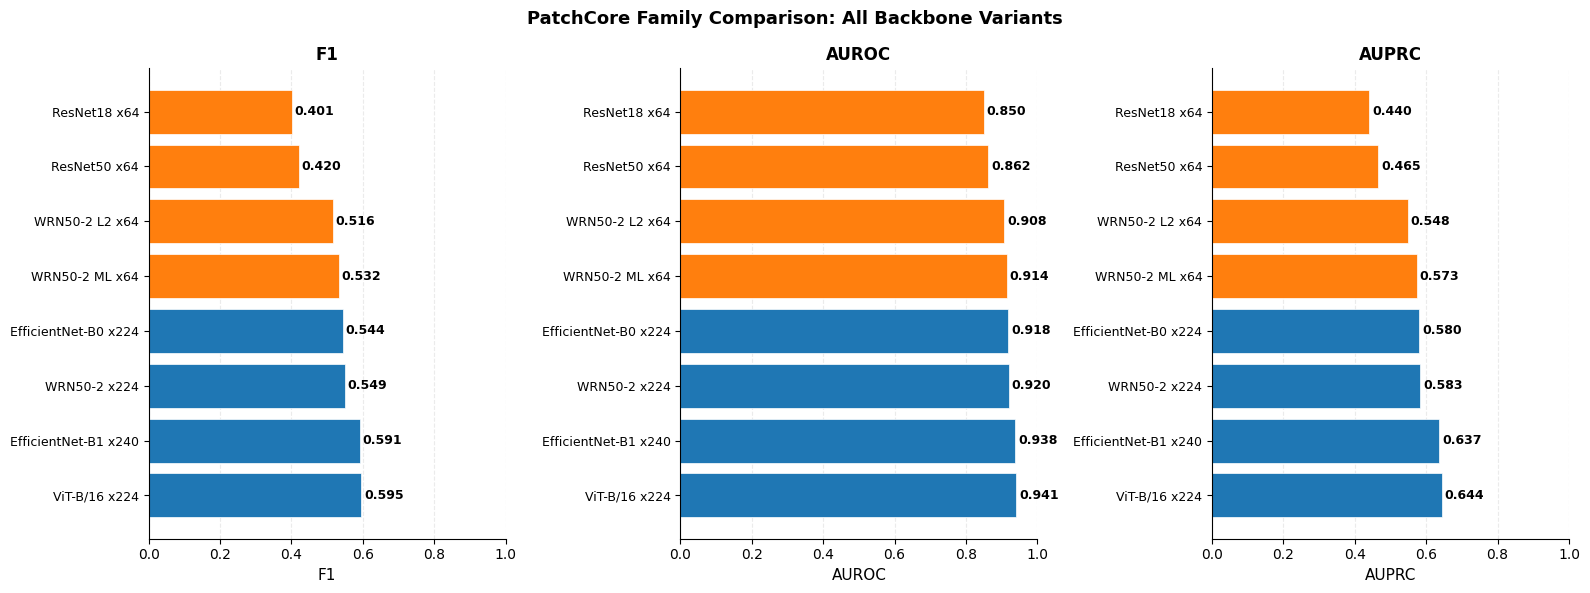

In [13]:
# Load all PatchCore backbone variants
patchcore_configs = [
    ('ResNet18 x64', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/resnet18/x64/main/artifacts/patchcore_resnet18/results/metrics.csv', '#ff7f0e'),
    ('ResNet50 x64', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/resnet50/x64/main/artifacts/patchcore_resnet50/results/metrics.csv', '#ff7f0e'),
    ('WRN50-2 L2 x64', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x64/singlelayer/artifacts/patchcore-wideresnet50-singlelayer/topk_mb50k_r005_x64/results/metrics.csv', '#ff7f0e'),
    ('WRN50-2 ML x64', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x64/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x64/results/metrics.csv', '#ff7f0e'),
    ('EfficientNet-B0 x224', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/efficientnet_b0/x224/main/artifacts/patchcore_efficientnet_b0/results/metrics.csv', '#1f77b4'),
    ('EfficientNet-B1 x240', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/efficientnet_b1/x240/main/artifacts/patchcore_efficientnet_b1_one_layer/results/metrics.csv', '#1f77b4'),
    ('WRN50-2 x224', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x224/results/metrics.csv', '#1f77b4'),
    ('ViT-B/16 x224', PROJ_ROOT / 'experiments/anomaly_detection/patchcore/vit_b16/x224/main/artifacts/patchcore_vit_b16_5pct/main_5pct/results/metrics.csv', '#1f77b4'),
]

patchcore_data = {}
patchcore_colors = {}
for label, metrics_csv, color in patchcore_configs:
    metrics = load_metrics(metrics_csv)
    if metrics is not None:
        patchcore_data[label] = metrics
        patchcore_colors[label] = color
        print(f"Loaded {label}: F1={metrics['F1']:.3f}")
    else:
        # Fallback hardcoded values if metrics.csv not found
        fallback_map = {
            'ResNet18 x64': {'F1': 0.401, 'AUROC': 0.850, 'AUPRC': 0.440},
            'ResNet50 x64': {'F1': 0.420, 'AUROC': 0.862, 'AUPRC': 0.465},
            'WRN50-2 L2 x64': {'F1': 0.516, 'AUROC': 0.908, 'AUPRC': 0.548},
            'WRN50-2 ML x64': {'F1': 0.532, 'AUROC': 0.914, 'AUPRC': 0.573},
            'EfficientNet-B0 x224': {'F1': 0.544, 'AUROC': 0.918, 'AUPRC': 0.580},
            'EfficientNet-B1 x240': {'F1': 0.591, 'AUROC': 0.938, 'AUPRC': 0.637},
            'WRN50-2 x224': {'F1': 0.549, 'AUROC': 0.920, 'AUPRC': 0.583},
            'ViT-B/16 x224': {'F1': 0.595, 'AUROC': 0.941, 'AUPRC': 0.644},
        }
        metrics = fallback_map.get(label)
        if metrics:
            patchcore_data[label] = metrics
            patchcore_colors[label] = color
            print(f"Using fallback for {label}: F1={metrics['F1']:.3f}")

# Sort by F1 descending
patchcore_sorted = sorted(patchcore_data.items(), key=lambda x: x[1]['F1'], reverse=True)

# Plot: F1, AUROC, AUPRC comparison (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, metric in zip(axes, ['F1', 'AUROC', 'AUPRC']):
    labels = [x[0] for x in patchcore_sorted]
    values = [x[1][metric] for x in patchcore_sorted]
    colors = [patchcore_colors[l] for l in labels]
    
    bars = ax.barh(range(len(labels)), values, color=colors, edgecolor='white', linewidth=0.5)
    
    for bar, val in zip(bars, values):
        ax.text(val + 0.008, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
    
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.xaxis.grid(True, alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)
    ax.set_xlim(0, 1.0)

plt.suptitle('PatchCore Family Comparison: All Backbone Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = OUTPUT_DIR / 'patchcore_family_comparison.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Plot 12 - Overall Experiment Comparison

Two-panel summary of all significant runs.
Left: all models ranked by deployed F1 (horizontal bar).
Right: AUPRC vs F1 scatter for all runs, point size proportional to AUROC.
Output: overall_experiment_comparison.png

In [ ]:
# -- Overall Experiment Comparison: bar chart + AUPRC/F1 scatter --------------
ALL_RUNS = [
    ("AE baseline x64",      PROJ_ROOT/"experiments/anomaly_detection/autoencoder/x64/baseline/artifacts/autoencoder_baseline/results/metrics.csv",                                                                         "#d62728"),
    ("AE+BatchNorm x64",     PROJ_ROOT/"experiments/anomaly_detection/autoencoder/x64/batchnorm/artifacts/autoencoder_batchnorm/results/metrics.csv",                                                                       "#d62728"),
    ("AE+BN+Dropout x64",    PROJ_ROOT/"experiments/anomaly_detection/autoencoder/x64/batchnorm_dropout/artifacts/autoencoder_batchnorm_dropout/dropout_0p00/results/metrics.csv",                                         "#d62728"),
    ("AE residual x64",      PROJ_ROOT/"experiments/anomaly_detection/autoencoder/x64/residual/artifacts/autoencoder_residual/results/metrics.csv",                                                                         "#d62728"),
    ("AE x224",              PROJ_ROOT/"experiments/anomaly_detection/autoencoder/x224/main/artifacts/autoencoder_x224/results/metrics.csv",                                                                                "#d62728"),
    ("Deep SVDD x64",        PROJ_ROOT/"experiments/anomaly_detection/deep_svdd/x64/one_class/artifacts/deep_svdd/results/metrics.csv",                                                                                     "#8c564b"),
    ("FastFlow + WRN50-2",   PROJ_ROOT/"experiments/anomaly_detection/fastflow/wideresnet50/x64/main/artifacts/fastflow_wideresnet50/results/metrics.csv",                                                                  "#e377c2"),
    ("WRN50-2 center-dist",  PROJ_ROOT/"experiments/anomaly_detection/backbone_embedding/wide_resnet50_2/x64/baseline/artifacts/wide_resnet50_2_embedding_baseline/evaluation/metrics.csv",                                 "#17becf"),
    ("TS + ResNet18 x64",    PROJ_ROOT/"experiments/anomaly_detection/teacher_student/resnet18/x64/main/artifacts/ts_resnet18/results/metrics.csv",                                                                         "#ff7f0e"),
    ("TS + ResNet18 x224",   PROJ_ROOT/"experiments/anomaly_detection/teacher_student/resnet18/x224/main/artifacts/ts_resnet18_x224/results/metrics.csv",                                                                   "#ff7f0e"),
    ("TS + ResNet50",        PROJ_ROOT/"experiments/anomaly_detection/teacher_student/resnet50/x64/main/artifacts/ts_resnet50/results/metrics.csv",                                                                         "#ff7f0e"),
    ("TS + WRN50-2 L2",      PROJ_ROOT/"experiments/anomaly_detection/teacher_student/wideresnet50/x64/singlelayer/artifacts/ts_wideresnet50_singlelayer/results/metrics.csv",                                              "#ff7f0e"),
    ("TS + WRN50-2 ML",      PROJ_ROOT/"experiments/anomaly_detection/teacher_student/wideresnet50/x64/multilayer/artifacts/ts_wideresnet50_multilayer/results/metrics.csv",                                                "#ff7f0e"),
    ("PC + AE-encoder x64",  PROJ_ROOT/"experiments/anomaly_detection/patchcore/encoder_ae_batchnorm/x64/main/artifacts/patchcore_ae_encoder/results/metrics.csv",                                                         "#2ca02c"),
    ("PC + ResNet18 x64",    PROJ_ROOT/"experiments/anomaly_detection/patchcore/resnet18/x64/main/artifacts/patchcore_resnet18/results/metrics.csv",                                                                       "#2ca02c"),
    ("PC + ResNet50 x64",    PROJ_ROOT/"experiments/anomaly_detection/patchcore/resnet50/x64/main/artifacts/patchcore_resnet50/results/metrics.csv",                                                                       "#2ca02c"),
    ("PC + WRN50-2 x64",     PROJ_ROOT/"experiments/anomaly_detection/patchcore/wideresnet50/x64/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x64/results/metrics.csv",                          "#2ca02c"),
    ("PC + EffNetB0 x224",   PROJ_ROOT/"experiments/anomaly_detection/patchcore/efficientnet_b0/x224/main/artifacts/patchcore_efficientnet_b0/results/metrics.csv",                                                        "#1f77b4"),
    ("PC + WRN50-2 x224",    PROJ_ROOT/"experiments/anomaly_detection/patchcore/wideresnet50/x224/multilayer/artifacts/patchcore-wideresnet50-multilayer/topk_mb50k_r005_x224/results/metrics.csv",                        "#1f77b4"),
    ("PC + EffNetB1 x240",   PROJ_ROOT/"experiments/anomaly_detection/patchcore/efficientnet_b1/x240/main_one_layer/artifacts/patchcore_efficientnet_b1_one_layer/results/metrics.csv",                                    "#1f77b4"),
    ("PC + ViT-B/16 x224",   PROJ_ROOT/"experiments/anomaly_detection/patchcore/vit_b16/x224/main/artifacts/patchcore_vit_b16_5pct/main_5pct/results/metrics.csv",                                                        "#1f77b4"),
]

FALLBACKS = {
    "AE baseline x64":     {"F1": 0.460, "AUROC": 0.850, "AUPRC": 0.480},
    "AE+BatchNorm x64":    {"F1": 0.502, "AUROC": 0.890, "AUPRC": 0.530},
    "AE+BN+Dropout x64":   {"F1": 0.499, "AUROC": 0.888, "AUPRC": 0.526},
    "AE residual x64":     {"F1": 0.486, "AUROC": 0.875, "AUPRC": 0.510},
    "AE x224":             {"F1": 0.505, "AUROC": 0.892, "AUPRC": 0.535},
    "Deep SVDD x64":       {"F1": 0.240, "AUROC": 0.620, "AUPRC": 0.200},
    "FastFlow + WRN50-2":  {"F1": 0.482, "AUROC": 0.900, "AUPRC": 0.510},
    "WRN50-2 center-dist": {"F1": 0.243, "AUROC": 0.780, "AUPRC": 0.370},
    "TS + ResNet18 x64":   {"F1": 0.495, "AUROC": 0.894, "AUPRC": 0.519},
    "TS + ResNet18 x224":  {"F1": 0.507, "AUROC": 0.908, "AUPRC": 0.510},
    "TS + ResNet50":       {"F1": 0.525, "AUROC": 0.909, "AUPRC": 0.599},
    "TS + WRN50-2 L2":     {"F1": 0.508, "AUROC": 0.920, "AUPRC": 0.540},
    "TS + WRN50-2 ML":     {"F1": 0.524, "AUROC": 0.923, "AUPRC": 0.546},
    "PC + AE-encoder x64": {"F1": 0.336, "AUROC": 0.810, "AUPRC": 0.360},
    "PC + ResNet18 x64":   {"F1": 0.401, "AUROC": 0.850, "AUPRC": 0.440},
    "PC + ResNet50 x64":   {"F1": 0.420, "AUROC": 0.862, "AUPRC": 0.465},
    "PC + WRN50-2 x64":    {"F1": 0.532, "AUROC": 0.914, "AUPRC": 0.573},
    "PC + EffNetB0 x224":  {"F1": 0.544, "AUROC": 0.918, "AUPRC": 0.580},
    "PC + WRN50-2 x224":   {"F1": 0.549, "AUROC": 0.920, "AUPRC": 0.583},
    "PC + EffNetB1 x240":  {"F1": 0.591, "AUROC": 0.935, "AUPRC": 0.609},
    "PC + ViT-B/16 x224":  {"F1": 0.595, "AUROC": 0.956, "AUPRC": 0.671},
}

run_data = []
for label, csv_path, color in ALL_RUNS:
    m = load_metrics(csv_path)
    if m is None:
        m = FALLBACKS.get(label)
    if m:
        run_data.append({"label": label, "color": color, **m})

run_data.sort(key=lambda x: x["F1"])

fig, (ax_bar, ax_sc) = plt.subplots(1, 2, figsize=(16, 8),
                                     gridspec_kw={"width_ratios": [1.4, 1]})

# Left: horizontal bar chart
f1_bar     = [r["F1"]    for r in run_data]
colors_bar = [r["color"] for r in run_data]
bars = ax_bar.barh(range(len(run_data)), f1_bar, color=colors_bar,
                   edgecolor="white", linewidth=0.4, height=0.72)
for bar, val in zip(bars, f1_bar):
    ax_bar.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8, fontweight="bold")
ax_bar.set_yticks(range(len(run_data)))
ax_bar.set_yticklabels([r["label"] for r in run_data], fontsize=8.5)
ax_bar.set_xlabel("Val-threshold F1", fontsize=11)
ax_bar.set_title("Top runs by deployed F1", fontsize=12, fontweight="bold")
ax_bar.axvline(0.5, color="black", linestyle=":", linewidth=1, alpha=0.5)
ax_bar.set_xlim(0, max(f1_bar) + 0.07)
ax_bar.xaxis.grid(True, alpha=0.2, linestyle="--")
ax_bar.set_axisbelow(True)

# Right: AUPRC vs F1 scatter, size proportional to AUROC
auroc_sc = [r["AUROC"] for r in run_data]
sizes    = [(a ** 6) * 2000 for a in auroc_sc]
sc = ax_sc.scatter([r["F1"] for r in run_data],
                   [r["AUPRC"] for r in run_data],
                   s=sizes, c=auroc_sc, cmap="RdYlGn",
                   vmin=0.6, vmax=1.0, edgecolors="white",
                   linewidths=0.5, alpha=0.88, zorder=3)
plt.colorbar(sc, ax=ax_sc, label="AUROC", fraction=0.04, pad=0.02)
ax_sc.set_xlabel("Val-threshold F1", fontsize=11)
ax_sc.set_ylabel("AUPRC", fontsize=11)
ax_sc.set_title("All runs: AUPRC vs F1\n(point size = AUROC)", fontsize=12, fontweight="bold")
ax_sc.xaxis.grid(True, alpha=0.2, linestyle="--")
ax_sc.yaxis.grid(True, alpha=0.2, linestyle="--")
ax_sc.set_axisbelow(True)

plt.suptitle("Overall Experiment Comparison: All Model Families",
             fontsize=13, fontweight="bold")
plt.tight_layout()
out_path = OUTPUT_DIR / "overall_experiment_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")


## Plot 13 - Defect Type Gallery

One representative wafer map per defect type from the test split.
Provides visual context for readers unfamiliar with wafer defect patterns.
Output: defect_type_gallery.png

In [ ]:
# -- Defect type gallery: one wafer image per class --------------------------
from wafer_defect.data.wm811k import WaferMapDataset

metadata_csv = PROJ_ROOT / "data/processed/x64/wm811k/metadata_50k_5pct.csv"
meta_gallery = pd.read_csv(metadata_csv)
meta_gallery = meta_gallery[meta_gallery["split"] == "test"].copy().reset_index(drop=True)
meta_gallery["label"] = meta_gallery["failure_type"].fillna("Normal")
meta_gallery.loc[meta_gallery["label"] == "none", "label"] = "Normal"

test_dataset = WaferMapDataset(metadata_csv, split="test", image_size=64)

defect_types_gallery = ["Normal", "Edge-Ring", "Edge-Loc", "Center",
                         "Loc", "Scratch", "Donut", "Random", "Near-full"]

indices_to_plot = []
for dt in defect_types_gallery:
    matching = meta_gallery[meta_gallery["label"] == dt]
    if len(matching) > 0:
        idx = matching.sample(1, random_state=42).index[0]
        indices_to_plot.append((dt, idx))
    else:
        print(f"No examples found for {dt}")

n_cols = 3
n_rows = (len(indices_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
axes_flat = np.array(axes).flatten()

for ax, (dt, idx) in zip(axes_flat, indices_to_plot):
    image, label = test_dataset[idx]
    img = image.numpy()
    if img.shape[0] == 1:
        img = img[0]
    img = (img - img.min()) / (img.max() - img.min() + 1e-6)
    ax.imshow(img, cmap="gray")
    ax.set_title(dt, fontsize=11, fontweight="bold")
    ax.axis("off")

for ax in axes_flat[len(indices_to_plot):]:
    ax.axis("off")

plt.suptitle("Defect Type Gallery: Representative Examples from Test Set",
             fontsize=13, fontweight="bold", y=0.995)
plt.tight_layout()
out_path = OUTPUT_DIR / "defect_type_gallery.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
